# ECG Arrhythmia Classification — PTB-XL Dataset
**Model:** CNN + Transformer + Additive Attention  
**Dataset:** PTB-XL, 500 Hz, 12-lead ECG  
**Task:** 5-class diagnostic superclass (NORM / MI / STTC / CD / HYP)  
**Evaluation:** Accuracy · Precision · Recall · F1 · ROC-AUC · Confusion Matrix

## 1. Imports & Reproducibility

In [4]:
import os
import math
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm

import wfdb

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

from transformers import get_cosine_schedule_with_warmup

warnings.filterwarnings("ignore")

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla P100-PCIE-16GB
VRAM: 17.1 GB


## 2. Config

In [5]:
# ── All hyperparameters in one place ────────────────────────────────────────
CFG = dict(
    data_path   = "/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/"
                  "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/",
    output_dir  = "/kaggle/working/",
    fs          = 500,          # Hz
    seq_len     = 5000,         # samples per record
    n_leads     = 12,
    n_classes   = 5,
    test_size   = 0.15,
    batch_size  = 32,
    epochs      = 80,
    lr          = 3e-4,
    weight_decay= 1e-4,
    grad_clip   = 1.0,          # max gradient norm
    focal_gamma = 2.0,
    warmup_frac = 0.05,         # fraction of total steps for warmup
    num_workers = 2,
)

# Class mapping — integers for PyTorch
CLASS_MAP  = {"NORM": 0, "MI": 1, "STTC": 2, "CD": 3, "HYP": 4}
INV_MAP    = {v: k for k, v in CLASS_MAP.items()}
LEAD_NAMES = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]

os.makedirs(CFG["output_dir"], exist_ok=True)
print("Config loaded.")

Config loaded.


## 3. Data Loading & Preprocessing

In [6]:
# ── Load metadata ────────────────────────────────────────────────────────────
meta = pd.read_csv(CFG["data_path"] + "ptbxl_database.csv")
meta.scp_codes = meta.scp_codes.apply(eval)

agg = pd.read_csv(CFG["data_path"] + "scp_statements.csv", index_col=0)
agg = agg[agg.diagnostic == 1]

def aggregate_diagnostic(y_dic: dict) -> list:
    """Map SCP codes to diagnostic superclasses."""
    return list({agg.loc[k].diagnostic_class
                 for k in y_dic if k in agg.index})

meta["diagnostic_superclass"] = meta.scp_codes.apply(aggregate_diagnostic)

# Keep only unambiguous single-label records
meta = meta[meta.diagnostic_superclass.map(len) == 1].copy()
meta["label"] = meta.diagnostic_superclass.apply(lambda x: x[0])
meta = meta[meta.label.isin(CLASS_MAP)].copy()
meta["label"] = meta["label"].map(CLASS_MAP)

print("Class distribution:")
print(meta["label"].value_counts().rename(INV_MAP).sort_index())
print(f"\nTotal records: {len(meta):,}")

Class distribution:
label
CD      1709
HYP      536
MI      2538
NORM    9083
STTC    2406
Name: count, dtype: int64

Total records: 16,272


In [7]:
# ── Load raw signals ─────────────────────────────────────────────────────────
signals = []
for fname in tqdm(meta["filename_hr"], desc="Loading ECG records"):
    record = wfdb.rdsamp(CFG["data_path"] + fname)
    signals.append(record[0])                        # (5000, 12)

X_raw = np.array(signals, dtype=np.float32)          # (N, 5000, 12)
y_raw = meta["label"].values

# (N, 12, 5000) — channels-first for Conv1d
X_raw = np.transpose(X_raw, (0, 2, 1))

print(f"X shape: {X_raw.shape}")
print(f"y shape: {y_raw.shape}")

Loading ECG records: 100%|██████████| 16272/16272 [05:35<00:00, 48.50it/s]


X shape: (16272, 12, 5000)
y shape: (16272,)


In [8]:
# ── Per-sample z-score normalisation (per lead) ──────────────────────────────
# Prevents amplitude differences between patients from dominating the signal.
# Computed on raw signals; applied before splitting to avoid any leakage
# because normalisation is purely local (per-sample).
mean = X_raw.mean(axis=2, keepdims=True)             # (N, 12, 1)
std  = X_raw.std(axis=2,  keepdims=True) + 1e-8
X    = (X_raw - mean) / std

print("Signal normalised. Sample stats (first record, lead II):")
print(f"  mean={X[0,1].mean():.4f}  std={X[0,1].std():.4f}")

Signal normalised. Sample stats (first record, lead II):
  mean=0.0000  std=1.0000


In [9]:
# ── Train / Validation split ─────────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y_raw,
    test_size   = CFG["test_size"],
    stratify    = y_raw,
    random_state= SEED
)

print(f"Train: {X_train.shape}  |  Val: {X_val.shape}")

Train: (13831, 12, 5000)  |  Val: (2441, 12, 5000)


## 4. Exploratory Visualisation — Input Data

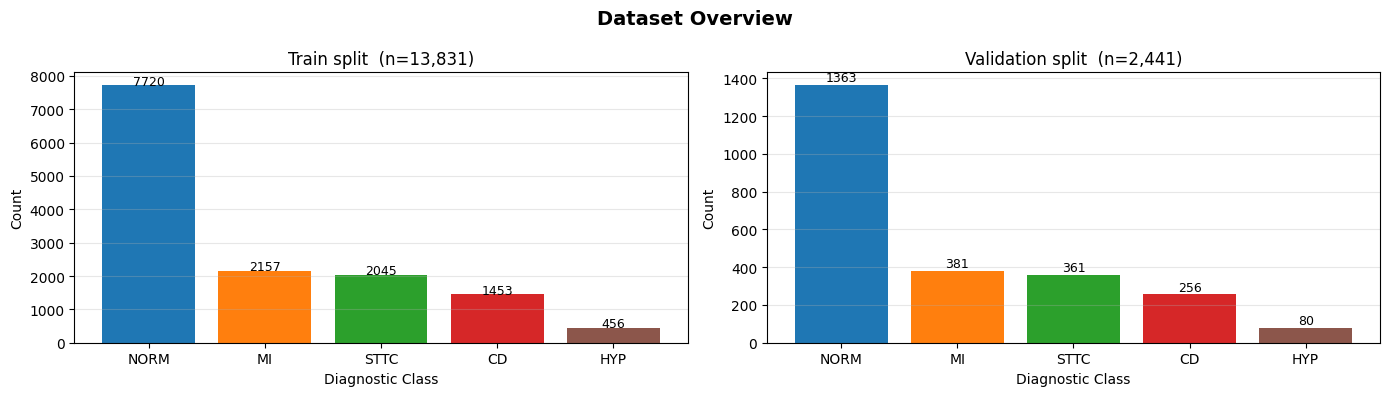

In [10]:
# ── Class distribution bar chart ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Dataset Overview", fontsize=14, fontweight="bold")

for ax, (split_y, title) in zip(axes,
        [(y_train, "Train"), (y_val, "Validation")]):
    counts = pd.Series(split_y).value_counts().sort_index()
    bars = ax.bar([INV_MAP[i] for i in counts.index], counts.values,
                  color=plt.cm.tab10(np.linspace(0, 0.5, 5)))
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(val), ha="center", fontsize=9)
    ax.set_title(f"{title} split  (n={len(split_y):,})")
    ax.set_ylabel("Count")
    ax.set_xlabel("Diagnostic Class")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(CFG["output_dir"] + "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

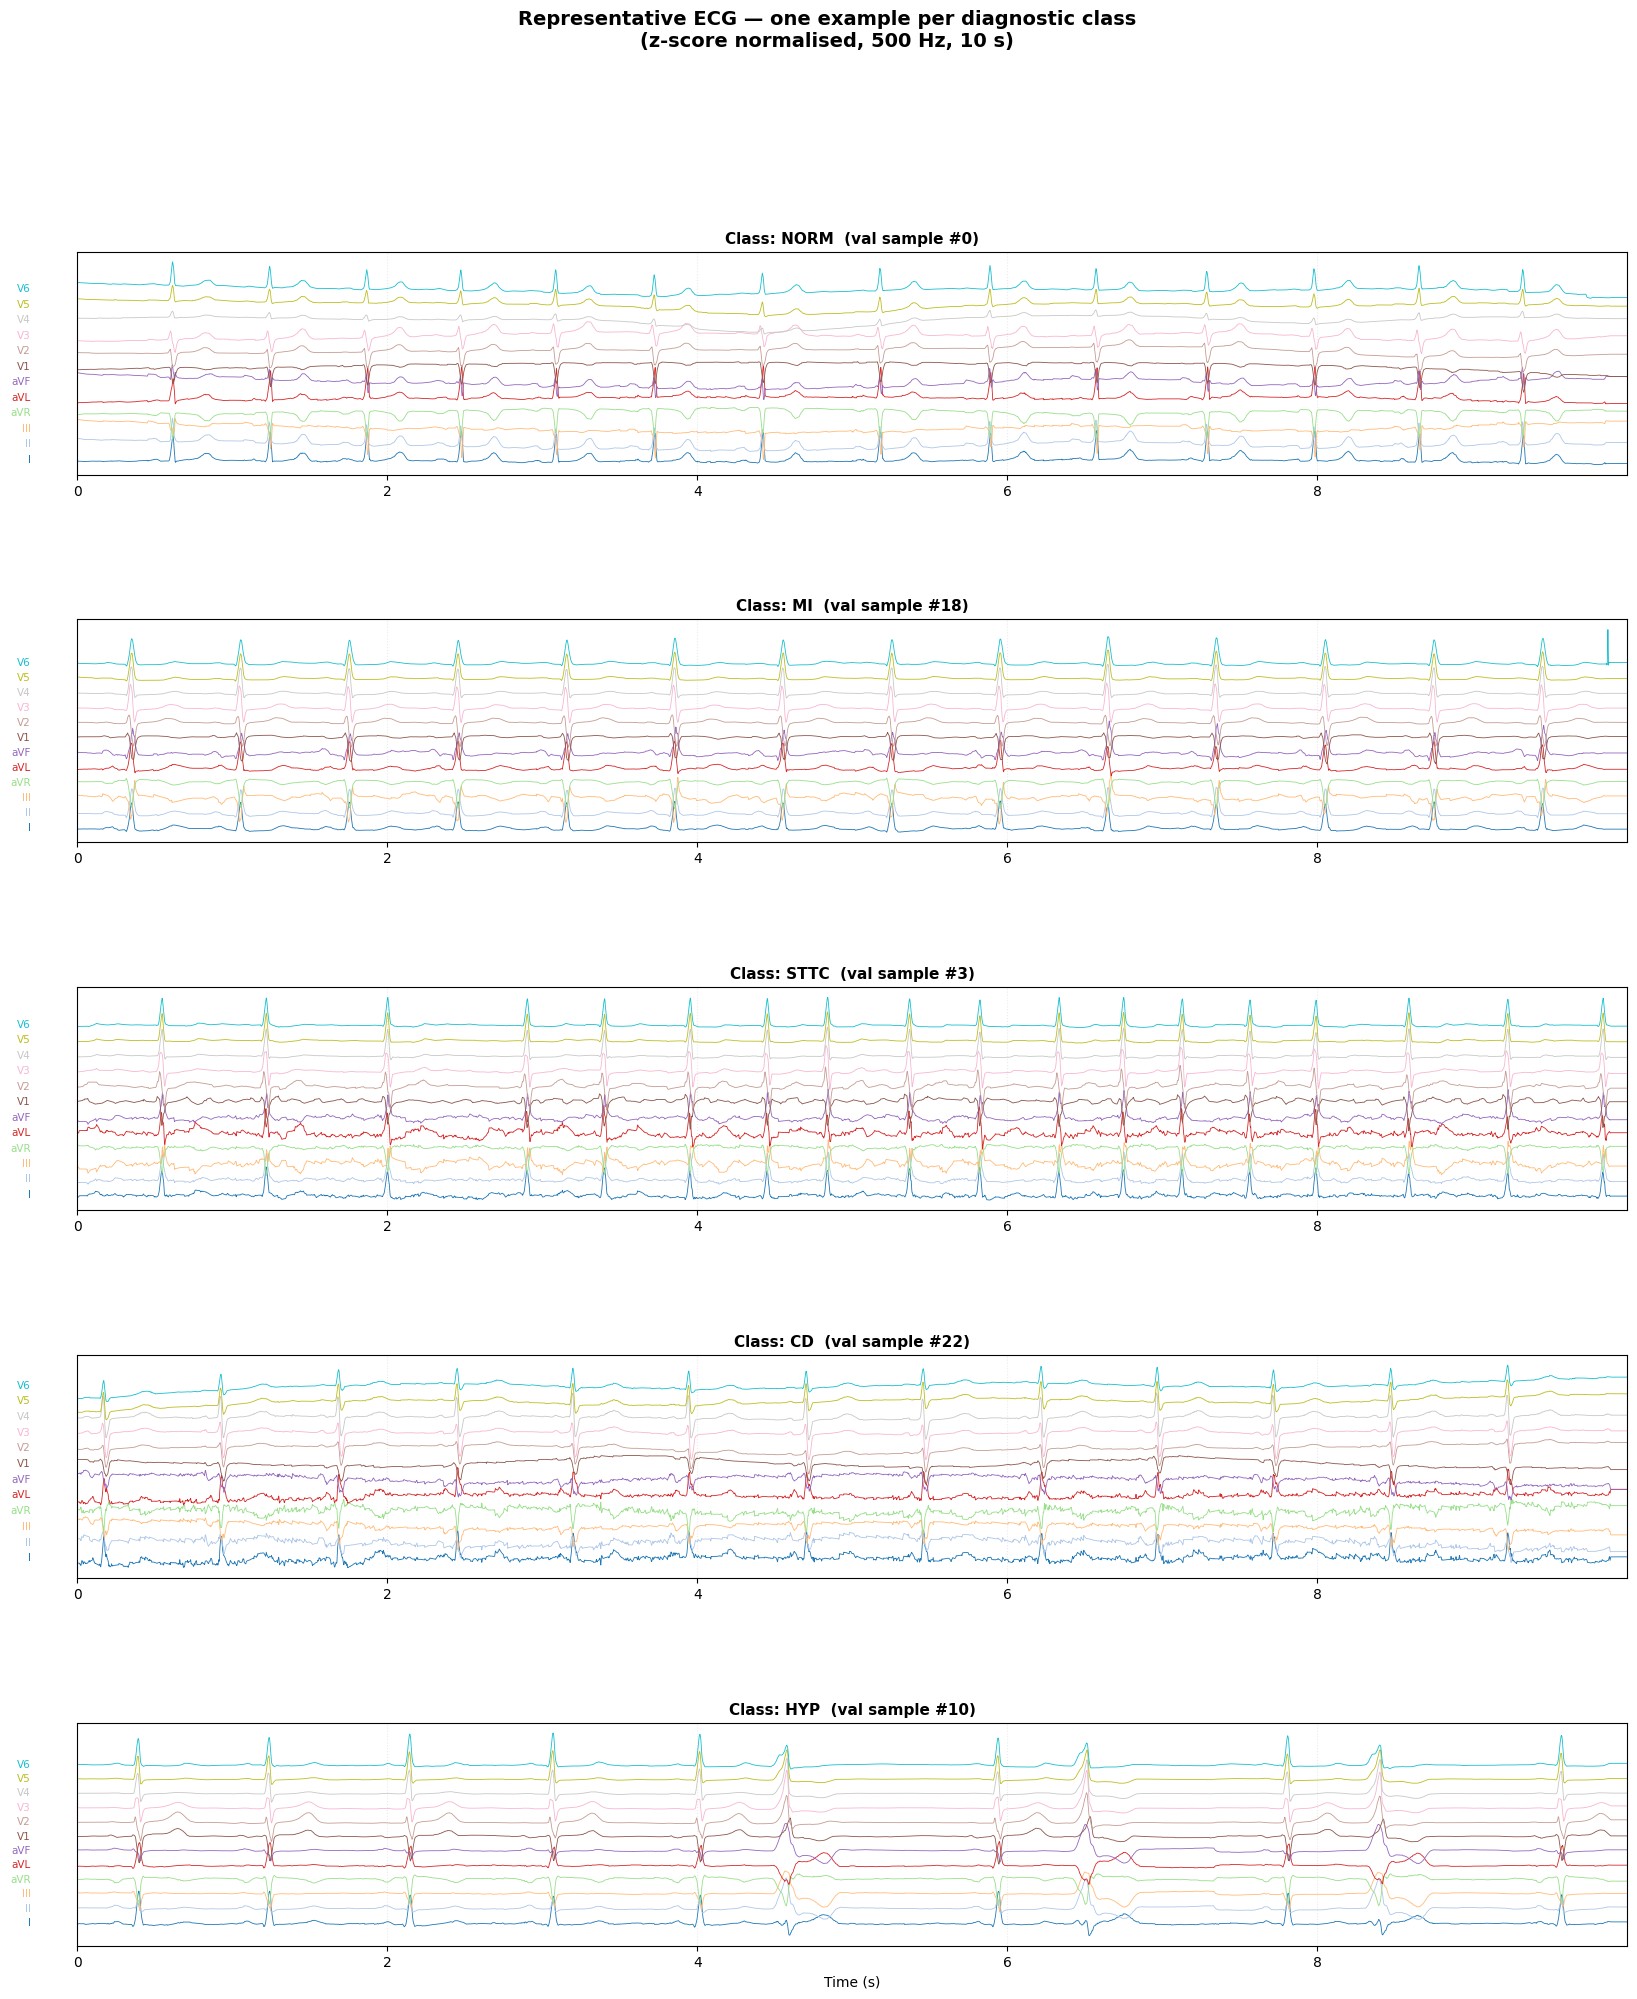

In [11]:
# ── One representative ECG per class ─────────────────────────────────────────
fig = plt.figure(figsize=(20, 22))
fig.suptitle("Representative ECG — one example per diagnostic class\n"
             "(z-score normalised, 500 Hz, 10 s)",
             fontsize=14, fontweight="bold", y=0.99)
gs = gridspec.GridSpec(5, 1, hspace=0.65)

for row, cls in enumerate(range(CFG["n_classes"])):
    idx    = np.where(y_val == cls)[0][0]
    signal = X_val[idx]                              # (12, 5000)
    t      = np.arange(signal.shape[1]) / CFG["fs"]  # seconds
    ax     = fig.add_subplot(gs[row])

    step   = signal.std() * 3.5
    offset = 0.0
    for lead_i in range(CFG["n_leads"]):
        color = plt.cm.tab20(lead_i / CFG["n_leads"])
        ax.plot(t, signal[lead_i] + offset, linewidth=0.6, color=color)
        ax.text(-0.3, offset, LEAD_NAMES[lead_i],
                va="center", ha="right", fontsize=7.5, color=color)
        offset += step

    ax.set_title(f"Class: {INV_MAP[cls]}  (val sample #{idx})",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Time (s)" if row == 4 else "")
    ax.set_yticks([])
    ax.set_xlim(0, t[-1])
    ax.grid(axis="x", alpha=0.25, linestyle=":")

plt.savefig(CFG["output_dir"] + "ecg_examples.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Dataset & Augmentation

In [12]:
class ECGDataset(Dataset):
    """
    PyTorch Dataset for 12-lead ECG classification.

    Augmentation (train only):
        - Gaussian noise injection  (σ = 0.01)
        - Amplitude scaling         (×0.90 – ×1.10)
        - Random time shift         (±200 samples = ±0.4 s)
    """

    def __init__(self, X: np.ndarray, y: np.ndarray, train: bool = True) -> None:
        self.X     = X
        self.y     = y
        self.train = train

    @staticmethod
    def augment(signal: np.ndarray) -> np.ndarray:
        signal = signal.copy()
        if np.random.rand() < 0.5:
            signal += np.random.normal(0, 0.01, signal.shape).astype(np.float32)
        if np.random.rand() < 0.5:
            signal *= np.random.uniform(0.9, 1.1)
        if np.random.rand() < 0.5:
            shift = np.random.randint(-200, 201)
            signal = np.roll(signal, shift, axis=1)
        return signal

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int):
        x = self.X[idx]
        if self.train:
            x = self.augment(x)
        return (
            torch.tensor(x,          dtype=torch.float32),
            torch.tensor(self.y[idx],dtype=torch.long)
        )

print("ECGDataset defined.")

ECGDataset defined.


In [13]:
# ── Class weights — used ONLY for FocalLoss alpha ────────────────────────────
# WeightedRandomSampler is removed to avoid double compensation.
class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

print("Class weights (balanced):")
for cls, w in zip(range(CFG["n_classes"]), class_weights_np):
    print(f"  {INV_MAP[cls]:<6}: {w:.4f}")

train_dataset = ECGDataset(X_train, y_train, train=True)
val_dataset   = ECGDataset(X_val,   y_val,   train=False)

train_loader = DataLoader(
    train_dataset,
    batch_size  = CFG["batch_size"],
    shuffle     = True,
    num_workers = CFG["num_workers"],
    pin_memory  = True
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = CFG["batch_size"],
    shuffle     = False,
    num_workers = CFG["num_workers"],
    pin_memory  = True
)

print(f"\nTrain batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

Class weights (balanced):
  NORM  : 0.3583
  MI    : 1.2824
  STTC  : 1.3527
  CD    : 1.9038
  HYP   : 6.0662

Train batches: 433  |  Val batches: 77


## 6. Model Architecture

In [14]:
class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding (Vaswani et al., 2017).
    Adds temporal order information before the Transformer.
    """

    def __init__(self, d_model: int, max_len: int = 2048) -> None:
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, d_model)
        return x + self.pe[:, :x.size(1)]


class ECGModel(nn.Module):
    """
    CNN + Positional Encoding + Transformer + Additive Attention classifier.

    Architecture:
        Conv1d stack  : (B, 12, 5000) → (B, 256, 1250)  temporal feature extraction
        Permute        : → (B, 1250, 256)                channels-last for Transformer
        Pos. Encoding  : adds sinusoidal position signal
        TransformerEncoder (2 layers, 8 heads)           global context
        Additive Attention : soft pooling → (B, 256)     sequence → vector
        Linear         : (B, 256) → (B, num_classes)
    """

    def __init__(self, num_classes: int = 5) -> None:
        super().__init__()

        # ── Temporal CNN backbone ────────────────────────────────────────────
        self.cnn = nn.Sequential(
            nn.Conv1d(12,  64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64), nn.GELU(), nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.GELU(), nn.MaxPool1d(2),

            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.GELU(),
        )
        # after two MaxPool1d(2): 5000 → 1250

        # ── Positional encoding ──────────────────────────────────────────────
        self.pos_enc = PositionalEncoding(d_model=256, max_len=1250)

        # ── Transformer encoder ──────────────────────────────────────────────
        enc_layer = nn.TransformerEncoderLayer(
            d_model        = 256,
            nhead          = 8,
            dim_feedforward= 512,
            dropout        = 0.2,
            activation     = "gelu",
            batch_first    = True,
            norm_first     = True,   # Pre-LN: more stable gradients
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=2)

        # ── Additive attention pooling ───────────────────────────────────────
        self.attention = nn.Sequential(
            nn.Linear(256, 128), nn.Tanh(),
            nn.Linear(128, 1)
        )

        # ── Classifier head ──────────────────────────────────────────────────
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(256, num_classes)

        self._init_weights()

    def _init_weights(self) -> None:
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.cnn(x)                              # (B, 256, 1250)
        x = x.permute(0, 2, 1)                       # (B, 1250, 256)
        x = self.pos_enc(x)
        x = self.transformer(x)

        attn_w = torch.softmax(self.attention(x), dim=1)   # (B, 1250, 1)
        x = torch.sum(x * attn_w, dim=1)                   # (B, 256)

        return self.fc(self.dropout(x))              # (B, num_classes)


model = ECGModel(num_classes=CFG["n_classes"]).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters:     1,234,502
Trainable parameters: 1,234,502


## 7. Loss, Optimiser & Scheduler

In [15]:
class FocalLoss(nn.Module):
    """
    Focal Loss (Lin et al., 2017) for class-imbalanced multi-class classification.

    L = mean[ (1 - p_t)^gamma * CE(logits, targets) ]

    alpha  — per-class weight tensor passed to cross_entropy
    gamma  — focusing parameter; 0 reduces to standard cross-entropy
    """

    def __init__(self, alpha: torch.Tensor = None, gamma: float = 2.0) -> None:
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce)
        return ((1.0 - pt) ** self.gamma * ce).mean()


# ── NOTE: alpha handles class imbalance; WeightedRandomSampler is NOT used ──
criterion = FocalLoss(alpha=class_weights, gamma=CFG["focal_gamma"])

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = CFG["lr"],
    weight_decay = CFG["weight_decay"]
)

total_steps  = len(train_loader) * CFG["epochs"]
warmup_steps = int(total_steps * CFG["warmup_frac"])

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

scaler = torch.amp.GradScaler("cuda")

print(f"Total training steps: {total_steps:,}")
print(f"Warmup steps:         {warmup_steps:,}")

Total training steps: 34,640
Warmup steps:         1,732


## 8. Training Loop

In [16]:
best_f1  = 0.0
history  = []

for epoch in range(1, CFG["epochs"] + 1):

    # ── Train phase ──────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0

    for x_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch:02d} train",
                                 leave=False):
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            logits = model(x_batch)
            loss   = criterion(logits, y_batch)

        scaler.scale(loss).backward()

        # ── Gradient clipping — critical for Transformer stability ───────────
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # ── Validation phase ─────────────────────────────────────────────────────
    model.eval()
    all_preds, all_targets, all_probs = [], [], []

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device, non_blocking=True)
            with torch.amp.autocast("cuda"):
                logits = model(x_batch)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            preds  = np.argmax(probs, axis=1)

            all_preds.extend(preds)
            all_targets.extend(y_batch.numpy())
            all_probs.append(probs)

    all_probs = np.vstack(all_probs)

    weighted_f1 = f1_score(all_targets, all_preds, average="weighted")
    macro_f1    = f1_score(all_targets, all_preds, average="macro")

    history.append({
        "epoch"      : epoch,
        "train_loss" : avg_train_loss,
        "weighted_f1": weighted_f1,
        "macro_f1"   : macro_f1,
        "lr"         : scheduler.get_last_lr()[0]
    })

    print(f"Epoch {epoch:02d}/{CFG['epochs']}  "
          f"loss={avg_train_loss:.4f}  "
          f"w-F1={weighted_f1:.4f}  "
          f"m-F1={macro_f1:.4f}")

    if weighted_f1 > best_f1:
        best_f1 = weighted_f1
        torch.save(model.state_dict(),
                   CFG["output_dir"] + "best_model_500hz.pth")
        print("  ✓ Model saved")

print(f"\nTraining complete. Best Weighted F1: {best_f1:.4f}")

Epoch 01/80  loss=1.1439  w-F1=0.3915  m-F1=0.3872
  ✓ Model saved


Epoch 02/80  loss=0.7838  w-F1=0.5843  m-F1=0.5094
  ✓ Model saved


Epoch 03/80  loss=0.6999  w-F1=0.5742  m-F1=0.5262


Epoch 04/80  loss=0.6809  w-F1=0.3706  m-F1=0.4282


Epoch 05/80  loss=0.6339  w-F1=0.5747  m-F1=0.5133


...

Epoch 76/80  loss=0.0006  w-F1=0.7645  m-F1=0.6470


Epoch 77/80  loss=0.0009  w-F1=0.7676  m-F1=0.6491


Epoch 78/80  loss=0.0006  w-F1=0.7666  m-F1=0.6486


Epoch 79/80  loss=0.0007  w-F1=0.7677  m-F1=0.6483


Epoch 80/80  loss=0.0008  w-F1=0.7655  m-F1=0.6458

Training complete. Best Weighted F1: 0.7681


## 9. Training History Visualisation

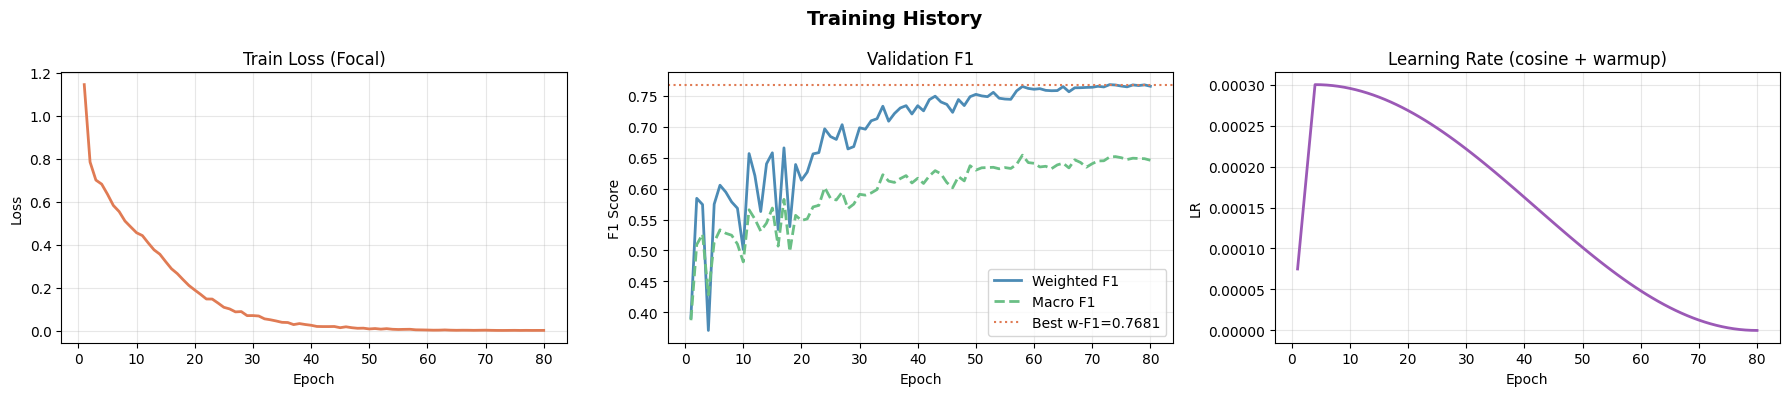

In [17]:
df_hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Training History", fontsize=14, fontweight="bold")

# Loss
axes[0].plot(df_hist["epoch"], df_hist["train_loss"],
             color="#e07b54", linewidth=2)
axes[0].set_title("Train Loss (Focal)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

# F1
axes[1].plot(df_hist["epoch"], df_hist["weighted_f1"],
             label="Weighted F1", color="#4c8bb5", linewidth=2)
axes[1].plot(df_hist["epoch"], df_hist["macro_f1"],
             label="Macro F1", color="#6abf85", linewidth=2, linestyle="--")
axes[1].axhline(best_f1, color="#e07b54", linestyle=":", linewidth=1.5,
                label=f"Best w-F1={best_f1:.4f}")
axes[1].set_title("Validation F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1 Score")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Learning rate
axes[2].plot(df_hist["epoch"], df_hist["lr"],
             color="#9b59b6", linewidth=2)
axes[2].set_title("Learning Rate (cosine + warmup)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("LR")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CFG["output_dir"] + "training_history.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Final Evaluation — Best Model

In [18]:
# ── Load best checkpoint ─────────────────────────────────────────────────────
model.load_state_dict(
    torch.load(CFG["output_dir"] + "best_model_500hz.pth",
               map_location=device)
)
model.eval()
print("Best checkpoint loaded.")

# ── Collect all predictions and probabilities ────────────────────────────────
final_preds, final_targets, final_probs = [], [], []

with torch.no_grad():
    for x_batch, y_batch in tqdm(val_loader, desc="Evaluating"):
        x_batch = x_batch.to(device, non_blocking=True)
        with torch.amp.autocast("cuda"):
            logits = model(x_batch)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

        final_preds.extend(preds)
        final_targets.extend(y_batch.numpy())
        final_probs.append(probs)

final_preds   = np.array(final_preds)
final_targets = np.array(final_targets)
final_probs   = np.vstack(final_probs)

print(f"Evaluated {len(final_targets):,} validation samples.")

Best checkpoint loaded.


Evaluating: 100%|██████████| 77/77 [00:05<00:00, 13.81it/s]

Evaluated 2,441 validation samples.


## 11. Academic Metrics

In [19]:
# ── 11.1  Overall scalar metrics ─────────────────────────────────────────────
class_names = [INV_MAP[i] for i in range(CFG["n_classes"])]

# Binarise labels for one-vs-rest ROC-AUC
y_true_bin = label_binarize(final_targets, classes=list(range(CFG["n_classes"])))

metrics = {
    "Accuracy"          : accuracy_score(final_targets, final_preds),
    "Precision (macro)" : precision_score(final_targets, final_preds, average="macro",  zero_division=0),
    "Precision (weighted)": precision_score(final_targets, final_preds, average="weighted", zero_division=0),
    "Recall (macro)"    : recall_score(final_targets, final_preds, average="macro",  zero_division=0),
    "Recall (weighted)" : recall_score(final_targets, final_preds, average="weighted", zero_division=0),
    "F1 (macro)"        : f1_score(final_targets, final_preds, average="macro"),
    "F1 (weighted)"     : f1_score(final_targets, final_preds, average="weighted"),
    "ROC-AUC (macro OvR)": roc_auc_score(y_true_bin, final_probs,
                                          multi_class="ovr", average="macro"),
    "ROC-AUC (weighted OvR)": roc_auc_score(y_true_bin, final_probs,
                                             multi_class="ovr", average="weighted"),
}

print("=" * 46)
print(f"{'Metric':<30} {'Value':>10}")
print("=" * 46)
for name, val in metrics.items():
    print(f"{name:<30} {val:>10.4f}")
print("=" * 46)

Metric                              Value
Accuracy                           0.7702
Precision (macro)                  0.6621
Precision (weighted)               0.7670
Recall (macro)                     0.6445
Recall (weighted)                  0.7702
F1 (macro)                         0.6510
F1 (weighted)                      0.7681
ROC-AUC (macro OvR)                0.8750
ROC-AUC (weighted OvR)             0.8987


In [20]:
# ── 11.2  Per-class metrics table ─────────────────────────────────────────────
report_dict = classification_report(
    final_targets, final_preds,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)
df_report = pd.DataFrame(report_dict).T

# Add per-class ROC-AUC
per_class_auc = roc_auc_score(y_true_bin, final_probs, average=None)
auc_series = pd.Series(
    list(per_class_auc) + [np.nan, np.nan, np.nan],
    index=df_report.index,
    name="roc_auc"
)
df_report["roc_auc"] = auc_series

print("\nPer-class metrics:")
print(df_report.round(4).to_string())

df_report.to_csv(CFG["output_dir"] + "classification_report_500hz.csv")
print("\nReport saved.")


Per-class metrics:
              precision  recall  f1-score    support  roc_auc
NORM             0.8430  0.8511    0.8470  1363.0000   0.9010
MI               0.7283  0.7034    0.7156   381.0000   0.9213
STTC             0.6140  0.6565    0.6345   361.0000   0.8847
CD               0.7617  0.7617    0.7617   256.0000   0.9201
HYP              0.3636  0.2500    0.2963    80.0000   0.7477
accuracy         0.7702  0.7702    0.7702     0.7702      NaN
macro avg        0.6621  0.6445    0.6510  2441.0000      NaN
weighted avg     0.7670  0.7702    0.7681  2441.0000      NaN

Report saved.


## 12. Confusion Matrix

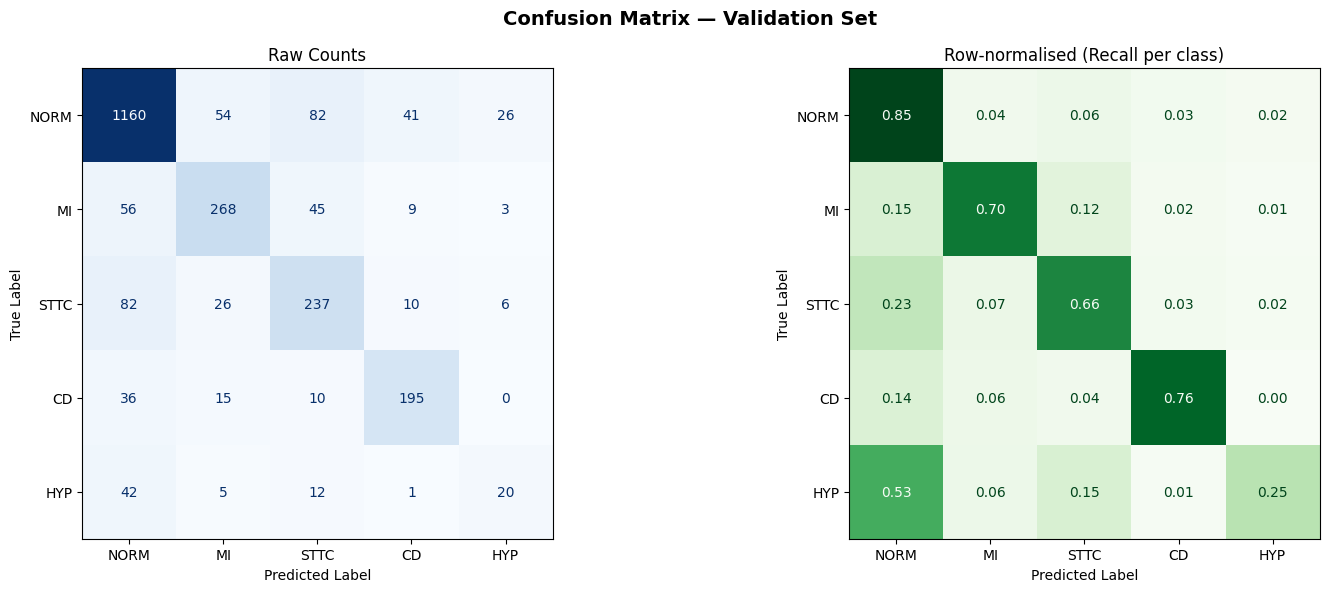

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Confusion Matrix — Validation Set",
             fontsize=14, fontweight="bold")

cm = confusion_matrix(final_targets, final_preds)

# ── Raw counts ───────────────────────────────────────────────────────────────
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Raw Counts")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# ── Row-normalised (recall per class) ────────────────────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp2.plot(ax=axes[1], colorbar=False, cmap="Greens", values_format=".2f")
axes[1].set_title("Row-normalised (Recall per class)")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.savefig(CFG["output_dir"] + "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. ROC Curves (One-vs-Rest)

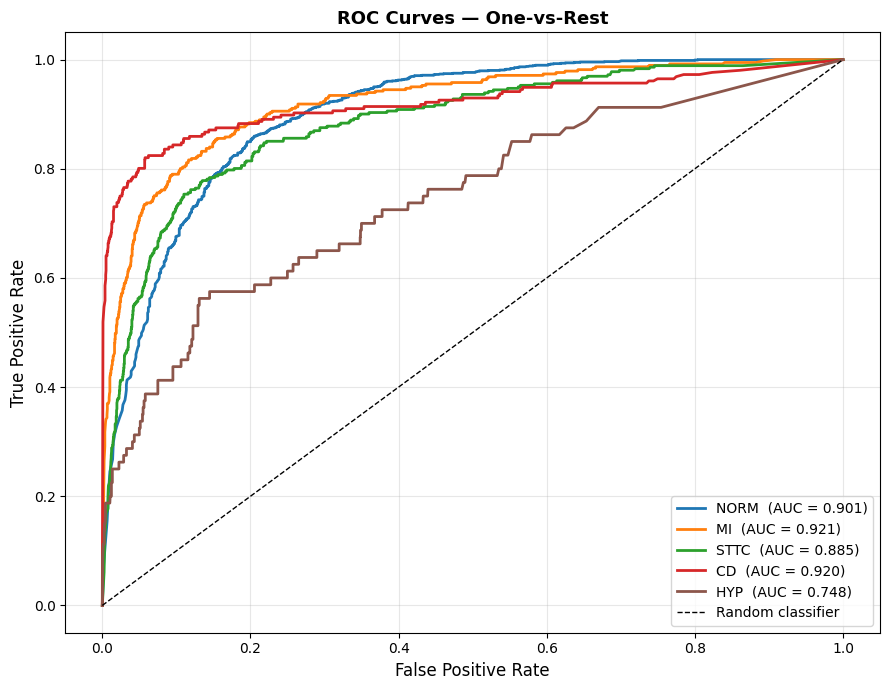

In [22]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.tab10(np.linspace(0, 0.5, CFG["n_classes"]))

for i, (cls_name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], final_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{cls_name}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — One-vs-Rest", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CFG["output_dir"] + "roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Save All Results

In [23]:
# Training history
pd.DataFrame(history).to_csv(
    CFG["output_dir"] + "training_history_500hz.csv", index=False
)

# Scalar metrics
pd.DataFrame.from_dict(metrics, orient="index", columns=["value"]).to_csv(
    CFG["output_dir"] + "scalar_metrics_500hz.csv"
)

# Predictions
df_preds = pd.DataFrame({
    "true_label" : final_targets,
    "pred_label" : final_preds,
    **{f"prob_{class_names[i]}": final_probs[:, i]
       for i in range(CFG["n_classes"])}
})
df_preds["true_name"] = df_preds["true_label"].map(INV_MAP)
df_preds["pred_name"] = df_preds["pred_label"].map(INV_MAP)
df_preds.to_csv(CFG["output_dir"] + "val_predictions_500hz.csv", index=False)

print("All artefacts saved to", CFG["output_dir"])
for f in sorted(os.listdir(CFG["output_dir"])):
    size = os.path.getsize(CFG["output_dir"] + f)
    print(f"  {f:<45} {size/1e3:>8.1f} KB")

All artefacts saved to /kaggle/working/
  .virtual_documents                                 4.1 KB
  best_model_500hz.pth                            6240.7 KB
  class_distribution.png                            67.8 KB
  classification_report_500hz.csv                    0.7 KB
  confusion_matrix.png                              93.7 KB
  ecg_examples.png                                1582.2 KB
  roc_curves.png                                   125.3 KB
  scalar_metrics_500hz.csv                           0.3 KB
  training_history.png                             145.5 KB
  training_history_500hz.csv                         6.7 KB
  val_predictions_500hz.csv                        122.1 KB
